# Algorithme EM

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from random import randint,random

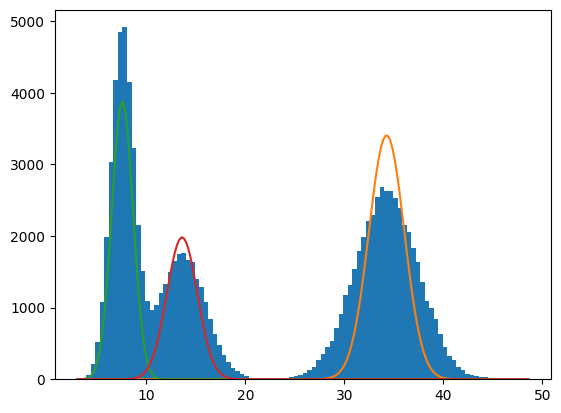

In [42]:
N = 100000
F = 3

mu = [randint(0,50)+random() for i in range(F)]
sigma = [randint(1,4)+random() for i in range(F)]
nb = [randint(1,N//(F-1)) for i in range(F)]
nb[F-1] = N - (sum(nb) - nb[F-1])

echantillon = np.array([])
for i in range(F):
  echantillon = np.concat((echantillon, norm(mu[i], sigma[i]).rvs(nb[i])))
np.random.shuffle(echantillon)

n, _, _ = plt.hist(echantillon, bins = 100)
x = np.linspace(min(echantillon), max(echantillon), 200)
for i in range(F):
    plt.plot(x, norm(mu[i],np.sqrt(sigma[i])).pdf(x)*nb[i]/F)
plt.show()

In [43]:
def EM_algorithm_step(pi, theta, x, n, F):
  new_rho = np.zeros((n,F))
  s = np.zeros(n)
  p = np.zeros((n,F))
  for i in range(n):
    for y in range(F):
      p[i,y] = 1/np.sqrt(2*np.pi*theta[y,1])*np.exp(-(x[i]-theta[y,0])**2/(2*theta[y,1]))
      s[i]+=pi[y]*p[i,y]
  for i in range(n):
    for y in range(F):
      new_rho[i,y] = pi[y]*p[i,y]/s[i]
  for y in range(F):
    new_pi=0
    for i in range(n):
      new_pi += new_rho[i,y]/n
    pi[y] = new_pi
  new_theta = np.zeros((F,2))
  for y in range(F):
    s1 = 0
    for i in range(n):
      s1 += new_rho[i,y]*x[i]
    new_theta[y,0] = s1/(n*pi[y])
    s2 = 0
    for i in range(n):
      s2 += new_rho[i,y]*(x[i] - new_theta[y,0])**2
    new_theta[y,1] = s2/(n*pi[y])
  return pi, new_theta

def EM_algorithm(n: int, F: int, x: np.array, pi0: np.array, theta0: np.array):
  pi, theta = pi0, theta0
  liste_pi, liste_theta = [np.copy(pi)], [np.copy(theta)]
  j=0
  while j<20:
    pi, theta = EM_algorithm_step(pi, theta, x, n, F)
    liste_pi.append(np.copy(pi))
    liste_theta.append(np.copy(theta))
    j += 1
  return pi, theta, liste_pi, liste_theta


In [44]:
indices = np.arange(N)
np.random.shuffle(indices)
echantillon_shuffled = []
for i in indices:
  echantillon_shuffled.append(echantillon[i])
pi0 = np.zeros(F)
theta0 = np.zeros((F,2))
for y in range(F):
  pi0[y] = 1/F

for y in range(F):
  theta0[y,0] += np.mean(echantillon_shuffled[y*N//F : (y+1)*N//F])
  for i in range(y*N//F, (y+1)*N//F):
    theta0[y,1] += 1/N*(echantillon_shuffled[i]-theta0[y,0])**2
pi, theta, liste_pi, liste_theta = EM_algorithm(N, F, echantillon, pi0, theta0)
print( "pi = ", pi)
print(" theta = ", theta)

pi =  [0.33302154 0.33388651 0.33309195]
 theta =  [[ 21.02124607 155.62476372]
 [ 21.28457671 156.16765921]
 [ 21.22357412 156.05415476]]


In [45]:
pi0 = np.ones(F)/F
mu0 = np.linspace(min(echantillon), max(echantillon), F)
sigma0 = np.ones(F)*(max(echantillon)-min(echantillon))/F/F
theta0 = np.stack((mu0, sigma0), axis = -1)

pi, theta, liste_pi, liste_theta = EM_algorithm(N, F, echantillon, pi0, theta0)
print( "pi = ", pi)
print(" theta = ", theta)

pi =  [0.54230589 0.40748112 0.05021299]
 theta =  [[10.12016529 11.99945582]
 [34.00337696  9.88862035]
 [36.49659383  6.0631613 ]]


In [46]:
def EM_algorithm_step_optim(pi, mu, sigma, x, n, F):
  p = np.zeros((F,n))
  for y in range(F):
    p[y] = np.exp(-(x-mu[y])**2/(2*sigma[y]))/np.sqrt(2*np.pi*sigma[y])
  p = p.transpose()
  rho = (pi*p).transpose()/np.sum(pi*p, axis = 1)
  new_pi = np.mean(rho, axis = 1)
  new_mu = np.sum(rho*x, axis = 1)/np.sum(rho, axis = 1)
  new_sigma = np.zeros(F)
  for y in range(F):
    new_sigma[y] = np.sum(rho[y]*(x - new_mu[y])**2)/np.sum(rho[y])
  return new_pi, new_mu, new_sigma

def EM_algorithm_optim(pi0: np.array, mu0: np.array, sigma0: np.array, x: np.array, n: int, F: int):
  pi, mu, sigma = pi0, mu0, sigma0
  liste_pi, liste_mu, liste_sigma = [np.copy(pi0)], [np.copy(mu0)], [np.copy(sigma0)]
  j=0
  while j<200 and (len(liste_pi) <= 2
    or np.linalg.norm(liste_pi[-1] - liste_pi[-2])+np.linalg.norm(liste_mu[-1] - liste_mu[-2])+np.linalg.norm(liste_sigma[-1] - liste_sigma[-2]) > 0.001):
    pi, mu, sigma = EM_algorithm_step_optim(pi, mu, sigma, x, n, F)
    liste_pi.append(np.copy(pi))
    liste_mu.append(np.copy(mu))
    liste_sigma.append(np.copy(sigma))
    j += 1
  return pi, mu, sigma, liste_pi, liste_mu, liste_sigma

In [47]:
pi0 = np.ones(F)/F
mu0 = np.linspace(min(echantillon), max(echantillon), F)
sigma0 = np.ones(F)*(max(echantillon)-min(echantillon))/F/F

_, _, _, liste_pi, liste_mu, liste_sigma = EM_algorithm_optim(pi0, mu0, sigma0, echantillon, N, F)

In [48]:
liste_theta = np.array(liste_theta)
liste_mu = np.split(liste_theta,2, axis = 2)[0]
liste_sigma = np.split(liste_theta,2, axis = 2)[1]

# K-moyennes

In [4]:
def nearest_neighbor(query, data):
    # Calculate L2 distances between the query vector and all data vectors
    if data.ndim > 1:
      distances = np.linalg.norm(data - query, axis = 1)
    else:
      distances = abs(data-query)

    # Find the index of the nearest neighbor
    nearest_index = np.argmin(distances)

    return nearest_index

def kmeans_step(centroid : np.array, x : np.array):
    nearest_index = np.array([nearest_neighbor(e, centroid) for e in x])
    return np.array([np.mean(x[nearest_index == i], axis = 0) for i in range(len(centroid))])


def kmeans(k, x):
  centroid = x[:k]*0
  np.random.shuffle(x)
  new_centroid = x[:k]
  i = 0
  while np.linalg.norm(centroid - new_centroid) > 0.001 and i < 100:
    i += 1
    centroid = new_centroid
    new_centroid = kmeans_step(centroid, x)
  return centroid


In [100]:
pi0 = np.ones(F)/F
mu0 = kmeans(F, echantillon)
sigma0 = np.ones(F)*(max(echantillon)-min(echantillon))/F/F

_, _, _, liste_pi, liste_mu, liste_sigma = EM_algorithm_optim(pi0, mu0, sigma0, echantillon, N, F)

[0. 0. 0.] [ 6.96529605  7.85303679 31.71164718]


# Visualisation des résultats

In [51]:
import ipywidgets as widgets  # interactive display
%config InlineBackend.figure_format = 'retina'

couleurs = ['red', 'green', 'blue']

In [101]:
@widgets.interact(etape=widgets.IntSlider(0, min=1, max=len(liste_pi),
                                              description="Etape"))

def progression(etape=0):
  x = np.linspace(min(echantillon), max(echantillon), 200)
  nb, _, _ = plt.hist(echantillon, bins = 100)
  for i in range(F):
      plt.plot(x, norm(liste_mu[etape-1][i],np.sqrt(liste_sigma[etape-1][i])).pdf(x)*liste_pi[etape-1][i]*N/2, color=couleurs[i])
  plt.show()

interactive(children=(IntSlider(value=1, description='Etape', max=34, min=1), Output()), _dom_classes=('widget…

In [53]:
import matplotlib.animation as animation
from IPython.display import HTML

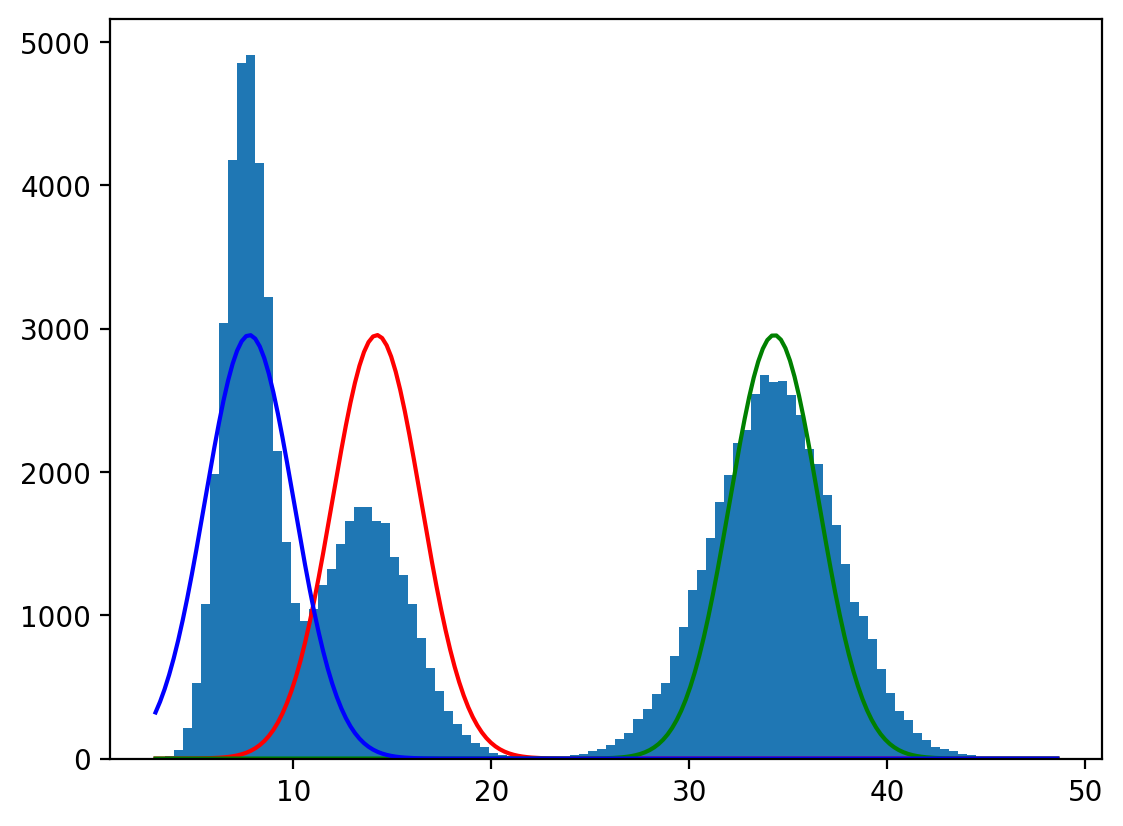

In [54]:
fig, ax = plt.subplots()

x = np.linspace(min(echantillon), max(echantillon), 200)
nb,  _, hist = ax.hist(echantillon, bins = 100)
gaussiennes = list()
for i in range(F):
  gaussiennes.append(ax.plot(x, norm(liste_mu[0][i],liste_sigma[0][i]).pdf(x)*liste_pi[0][i]*max(nb)*np.sqrt(2*np.pi*liste_sigma[0][i]), color=couleurs[i])[0])

def update(frame):
    pi = liste_pi[frame]
    mu = liste_mu[frame]
    sigma = liste_sigma[frame]
    for i in range(F):
        gaussiennes[i].set_ydata(norm(mu[i], np.sqrt(sigma[i])).pdf(x)*pi[i]*N/2)
    return gaussiennes

ani = animation.FuncAnimation(fig=fig, func=update, frames=len(liste_pi), interval=30)
ani.save("animation.mp4")
HTML(ani.to_jshtml())

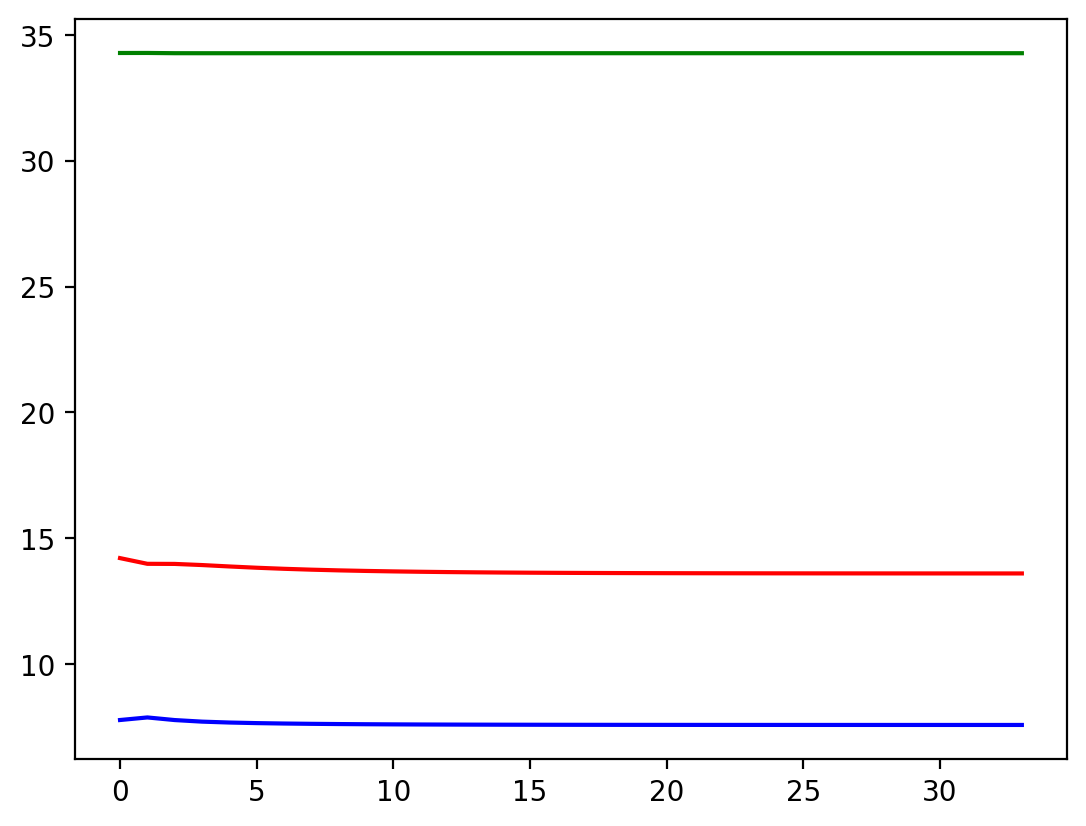

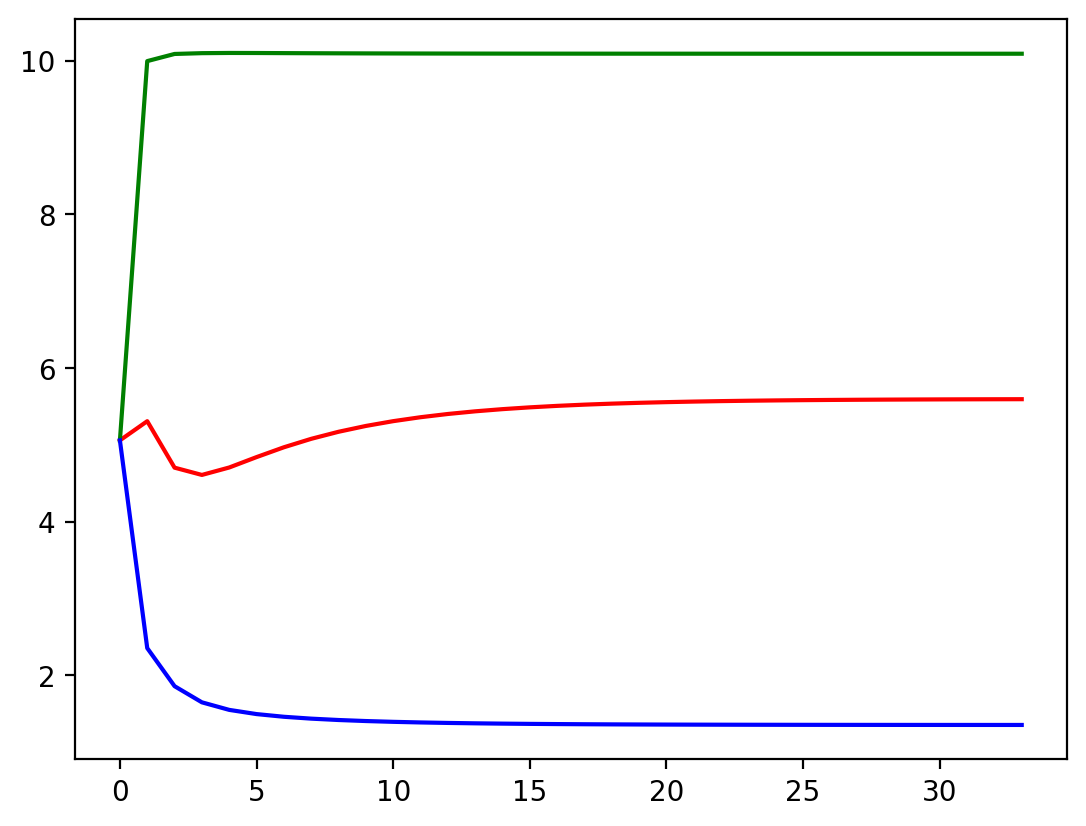

In [55]:
liste_mu = np.array(liste_mu)
liste_sigma = np.array(liste_sigma)
for i in range(F):
    plt.plot(liste_mu.transpose()[i], color = couleurs[i])
plt.show()
for i in range(F):
    plt.plot(liste_sigma.transpose()[i], color = couleurs[i])
plt.show()

# PCA

In [9]:
import pandas as pd

In [10]:
data = pd.read_table("/content/WineQT.csv", sep=',')
data.drop("Id", axis = "columns", inplace = True)
data = (data - np.mean(data, axis = 0))/np.std(data, axis = 0)
data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382,-0.815724
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601,-0.815724
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601,-0.815724
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601,0.425784
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382,-0.815724
...,...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,-0.171289,-0.231395,1.306316,-0.180503,-0.514707,0.695966,0.541862,0.515741,0.425784
1139,-0.865059,0.493785,-0.958109,-0.466421,-0.400719,1.208717,-0.241539,-0.114545,0.695966,0.952843,-0.870937,0.425784
1140,-1.208538,0.382399,-0.958109,-0.392638,0.064922,1.599113,-0.058432,-0.951246,0.887542,-0.456235,0.053515,-0.815724
1141,-1.380278,0.103932,-0.856379,-0.245072,-0.527712,2.282306,0.155192,-0.836914,1.334554,0.600574,0.700632,0.425784


In [11]:
from sklearn import decomposition
pca = decomposition.PCA()
pca.fit(data)

PCA()

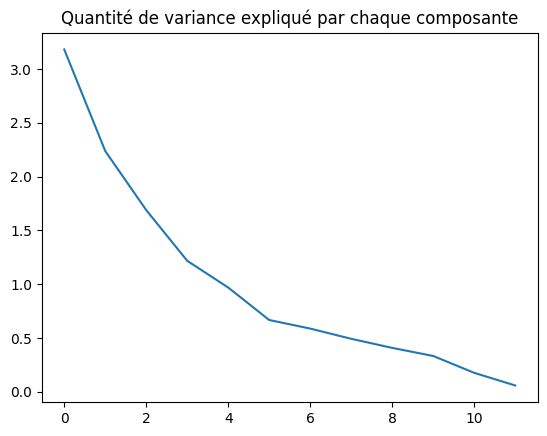

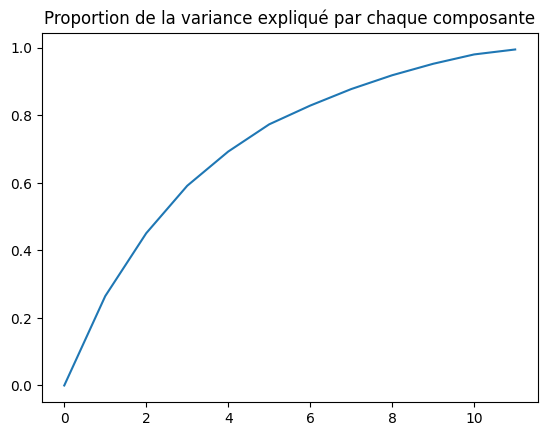

In [12]:
plt.plot(pca.explained_variance_)
plt.title("Quantité de variance expliqué par chaque composante")
plt.show()

n = len(pca.explained_variance_)
total = sum(pca.explained_variance_)
plt.plot([k for k in range(n)], [sum(pca.explained_variance_[:k])/total for k in range(n)])
plt.title("Proportion de la variance expliqué par chaque composante")
plt.show()

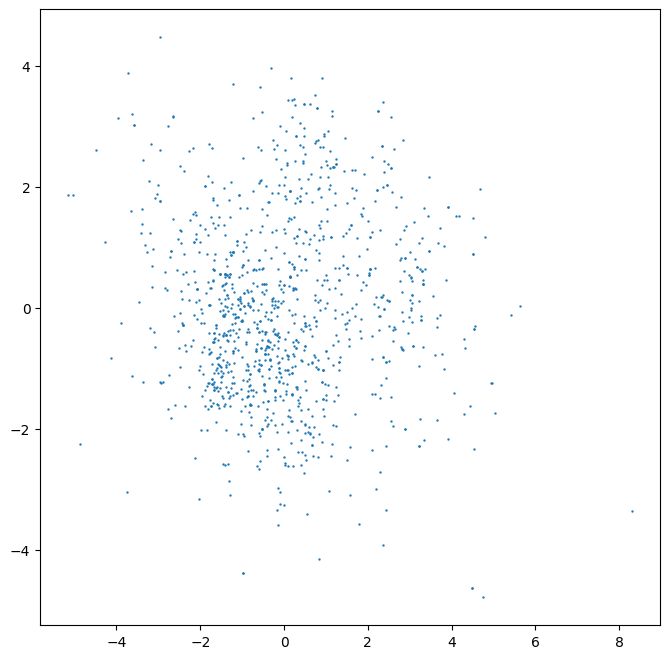

In [13]:
train_scores = pca.transform(data) # Array of scores of the training set

plt.figure(figsize=(8, 8))

plt.scatter(train_scores[:,0],train_scores[:,1],s=0.5)
plt.show()

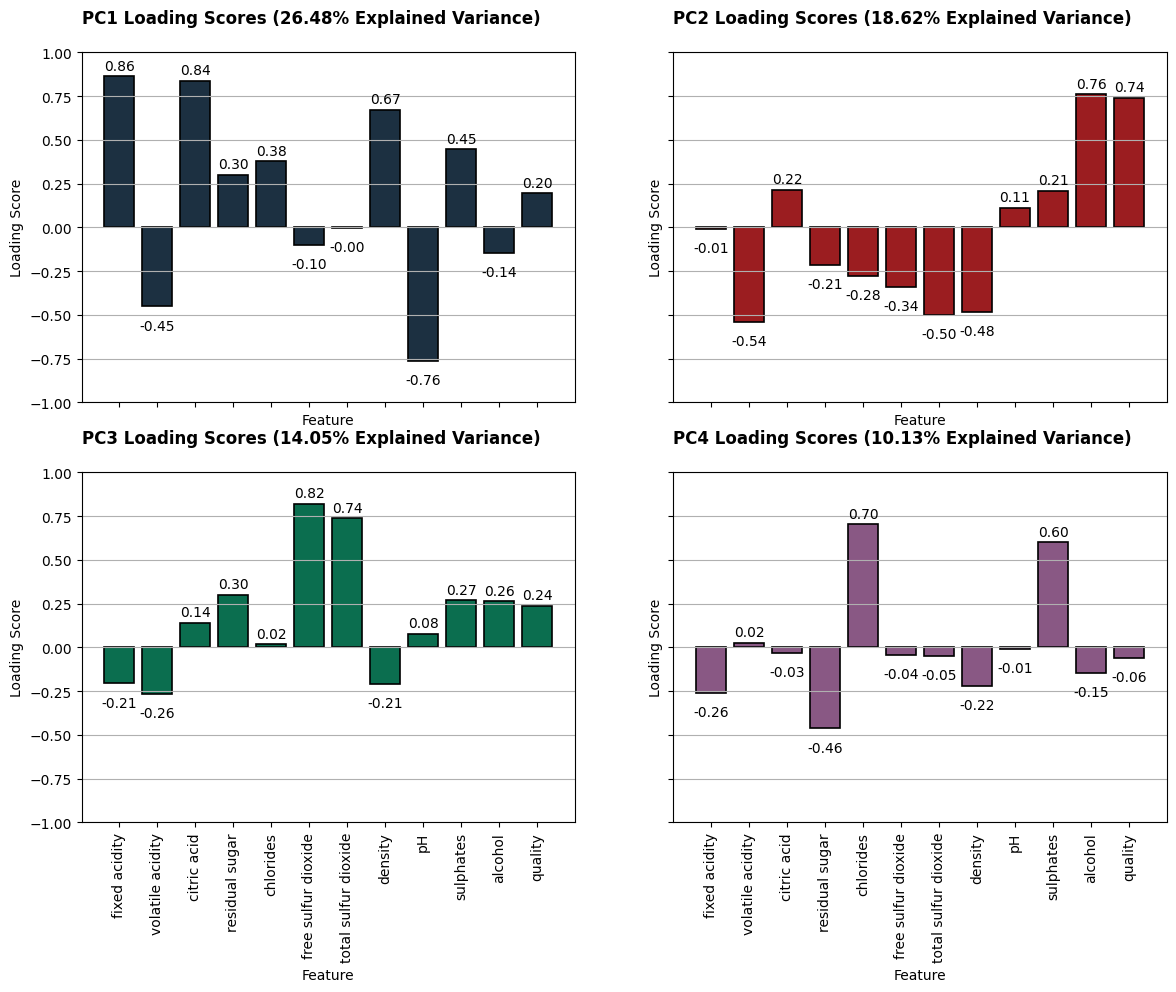

In [14]:
loadings = pd.DataFrame(
    data=pca.components_.T * np.sqrt(pca.explained_variance_),
    columns=[f"PC{i}" for i in range(1, len(data.columns) + 1)],
    index=data.columns
)

fig, axs = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
colors = ["#1C3041", "#9B1D20", "#0B6E4F", "#895884"]

for i, ax in enumerate(axs.flatten()):
    explained_variance = pca.explained_variance_ratio_[i] * 100
    pc = f"PC{i+1}"
    bars = ax.bar(loadings.index, loadings[pc], color=colors[i], edgecolor="#000000", linewidth=1.2)
    ax.set_title(f"{pc} Loading Scores ({explained_variance:.2f}% Explained Variance)", loc="left", fontdict={"weight": "bold"}, y=1.06)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Loading Score")
    ax.grid(axis="y")
    ax.tick_params(axis="x", rotation=90)
    ax.set_ylim(-1, 1)

    for bar in bars:
        yval = bar.get_height()
        offset = yval + 0.02 if yval > 0 else yval - 0.15
        ax.text(bar.get_x() + bar.get_width() / 2, offset, f"{yval:.2f}", ha="center", va="bottom")


plt.show()

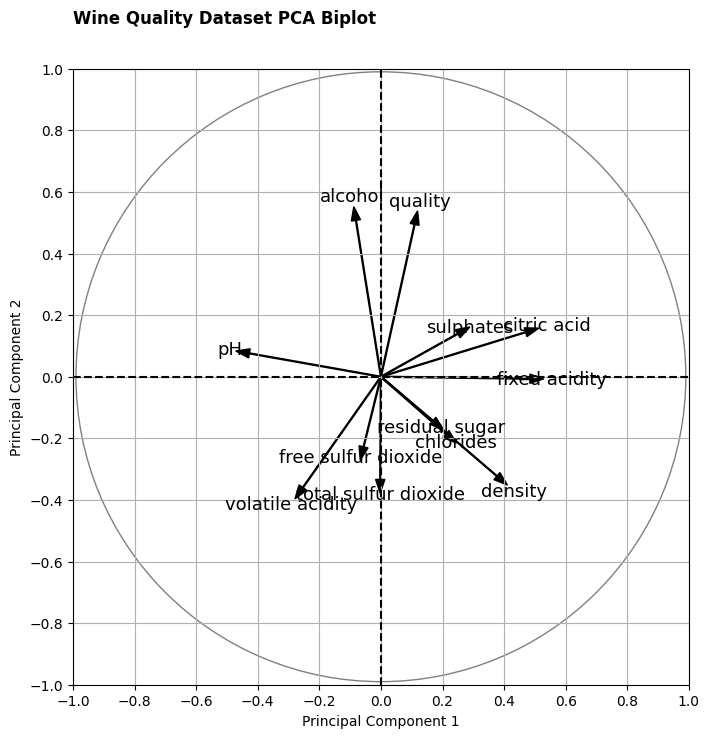

In [15]:
labels = data.columns
n = len(labels)
coeff = np.transpose(pca.components_)
pc1 = pca.components_[:, 0]
pc2 = pca.components_[:, 1]

plt.figure(figsize=(8, 8))

for i in range(n):
    plt.arrow(x=0, y=0, dx=coeff[i, 0], dy=coeff[i, 1], color="#000000", width=0.003, head_width=0.03)
    plt.text(x=coeff[i, 0] * 1.15, y=coeff[i, 1] * 1.15, s=labels[i], size=13, color="#000000", ha="center", va="center")

plt.axis("square")
plt.title(f"Wine Quality Dataset PCA Biplot", loc="left", fontdict={"weight": "bold"}, y=1.06)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xticks(np.arange(-1, 1.1, 0.2))
plt.yticks(np.arange(-1, 1.1, 0.2))

plt.axhline(y=0, color="black", linestyle="--")
plt.axvline(x=0, color="black", linestyle="--")
circle = plt.Circle((0, 0), 0.99, color="gray", fill=False)
plt.gca().add_artist(circle)

plt.grid()
plt.show()

# Clustering : k-moyennes

In [7]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

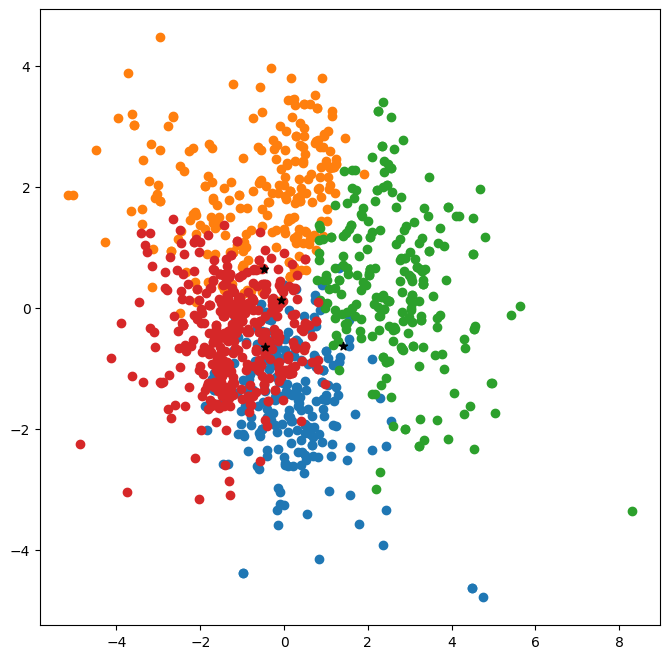

In [16]:
k = 4
kmeans_model = KMeans(
    init='k-means++', # How to compute initial centroids
    max_iter=300, # Maximal number of iterations
    n_clusters=k, # Number of clusters
    n_init=20 # Number of times the algorithm is run with different initial configurations
)
kmeans = kmeans_model.fit(data)

labels = kmeans.labels_ # Array which contains the index of the cluster of each point
centroids = kmeans.cluster_centers_ # Array which contains the coordinates of the centroids

train_scores = pca.transform(data) # Array of scores of the training set
colors = plt.cm.tab10(np.linspace(0, 1, 10)) # Table of colors

plt.figure(figsize=(8, 8))

# Scatter plots
for y in range(k):
  indices = np.where((labels == y))
  train_scores_extracted = train_scores[indices]
  plt.scatter(train_scores_extracted[:,0],train_scores_extracted[:,1],color=colors[y])

plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', c='black')
plt.show()

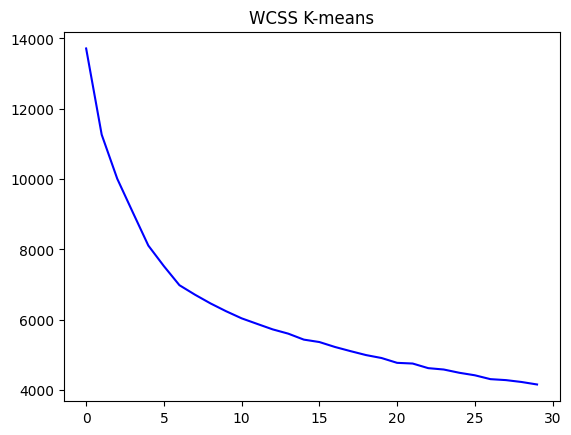

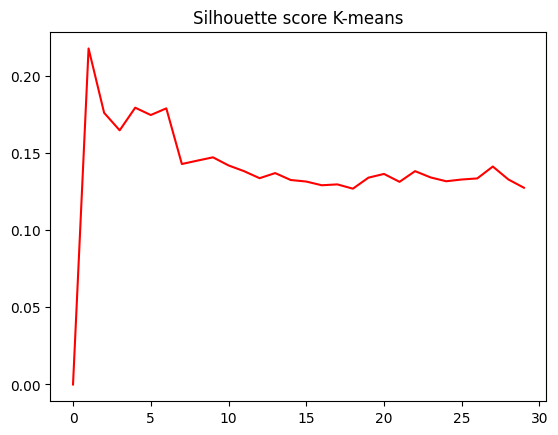

In [18]:
wcss_kmeans = np.zeros(30)
silhouette_kmeans = np.zeros(30)

for k in range(1, 31):
  kmeans_model = KMeans(
    init='k-means++', # How to compute initial centroids
    max_iter=300, # Maximal number of iterations
    n_clusters=k, # Number of clusters
    n_init=20 # Number of times the algorithm is run with different initial configurations
  )
  kmeans = kmeans_model.fit(data)

  wcss_kmeans[k-1] = kmeans.inertia_
  if k == 1:
    silhouette_kmeans[0] = 0
  else:
    silhouette_kmeans[k-1] = silhouette_score(data, kmeans.labels_)

plt.plot(wcss_kmeans, 'b')
plt.title("WCSS K-means")
plt.show()
plt.plot(silhouette_kmeans, 'r')
plt.title("Silhouette score K-means")
plt.show()

# Clustering : Classification hiérarchique

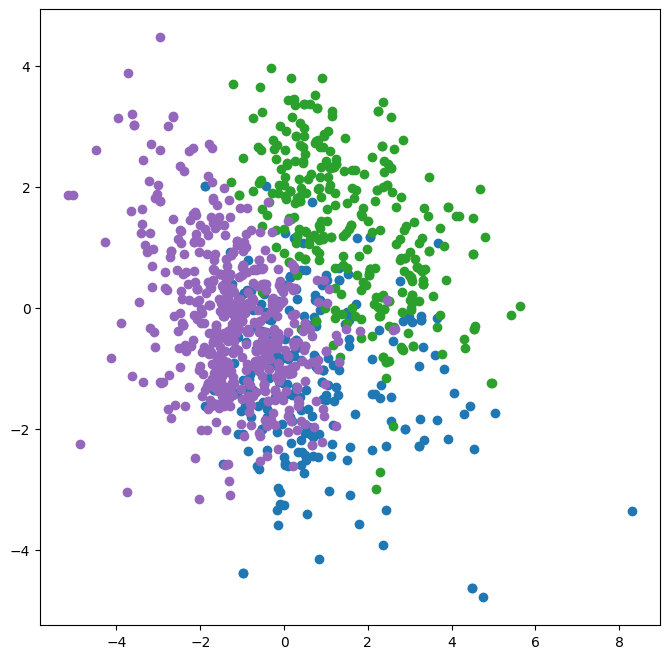

In [19]:
k = 6
agglo_ward_model = AgglomerativeClustering(linkage='ward', n_clusters=3)
agglo_ward = agglo_ward_model.fit(data)

labels = agglo_ward.labels_ # Array which contains the index of the cluster of each point

train_scores = pca.transform(data) # Array of scores of the training set
colors = plt.cm.tab10(np.linspace(0, 1, k)) # Table of colors

plt.figure(figsize=(8, 8))

# Scatter plots
for y in range(k):
  indices = np.where((labels == y))
  train_scores_extracted = train_scores[indices]
  plt.scatter(train_scores_extracted[:,0],train_scores_extracted[:,1],color=colors[y])

plt.show()

In [32]:
def labels_matrix(children):
  n_s = children.shape[0]+1

  # clust[k,i] will contain the index of the cluster to which i belongs after k iterations
  clust = np.zeros((n_s,n_s), dtype=int)
  clust[0] = np.arange(n_s)

  # Browse children for agglomerative clustering
  for k in range(n_s-1):
    c1 = children[k,0] # index of 1st cluster merging
    c2 = children[k,1] # index of 2nd cluster merging
    for i in range(n_s):
      clust[k+1,i] = clust[k,i] # By default, clusters do not change indices
      if clust[k,i]==c1:
        clust[k+1,i] = n_s+k
      if clust[k,i]==c2:
        clust[k+1,i] = n_s+k

  return clust

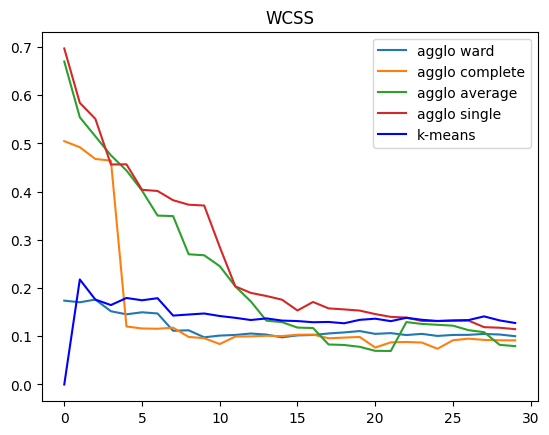

In [43]:
linkage = ["ward", "complete", "average", "single"]
for i in range(len(linkage)):
  agglo_model = AgglomerativeClustering(linkage=linkage[i], distance_threshold=0, n_clusters=None)
  agglo = agglo_model.fit(data)

  labels = labels_matrix(agglo.children_)
  silhouette_agglo = [silhouette_score(data, labels[-31+i]) for i in range(30)]
  silhouette_agglo.reverse()
  plt.plot(silhouette_agglo, label="agglo "+linkage[i])

plt.plot(silhouette_kmeans, 'b', label="k-means")
plt.legend()
plt.title("WCSS")
plt.show()